# East Denmark - TRUE 15-Minute Granularity Analysis (NO Hourly Aggregation)

**IMPORTANT**: This analysis maintains **genuine 15-minute precision** throughout all calculations. No data is floored, rounded, or averaged to hourly values. Every price point represents an actual 15-minute interval from the DayAheadPrices API.

## Key Features:
- ✅ **15-minute intervals**: 96 data points per day (4 per hour)
- ✅ **No aggregation**: All calculations preserve 15-minute granularity  
- ✅ **Intraday patterns**: Capture price movements within each hour
- ✅ **Precise optimization**: Find optimal 15-minute time slots for electricity usage
- ✅ **High-resolution analysis**: Volatility, patterns, and forecasts at 15-minute resolution

In [25]:
source("~/renv_start.R")

Setting up renv in: /novo/users/caku

⚡ All packages already loaded - nothing to do



In [27]:
knitr::opts_chunk$set(echo = FALSE, message = FALSE, warning = FALSE)
library(pacman)
pacman::p_load(
  tidyr,
  dplyr,
  ggplot2,
  httr,
  rpart.plot,
  pushoverr,
  caret,
  zoo,
  glue,
  rPref,
  lubridate,
  jsonlite,
  scales,
  viridis  # Colorblind-friendly palettes for heatmaps
)

Installing package into ‘/novo/users/caku/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)

Warning message:
“unable to access index for repository https://cran.r-project.org/src/contrib:
  internet routines cannot be loaded”
Warning message:
“package ‘rpart.plot’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”
Warning message:
“'BiocManager' not available.  Could not check Bioconductor.

Please use `install.packages('BiocManager')` and then retry.”
Warning message in p_install(package, character.only = TRUE, ...):
“”
Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘rpart.plot’”
Installing package into ‘/novo/users/caku/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)

Warning message:
“unable to access index for 

In [29]:
# =============================================================================
# CONFIGURATION - All constants and parameters
# =============================================================================

# API Configuration
PRICE_AREA <- "DK2"  # East Denmark (use "DK1" for West Denmark)
API_LIMIT <- 70000
EXCHANGE_RATE_FALLBACK <- 7.43988  # EUR to DKK fallback

# Transport tariffs (Radius nettarif per 30. september 2023, øre/kWh)
# Summer (April-September)
TRANSPORT_SUMMER_NIGHT <- 12.20   # 00:00-05:59
TRANSPORT_SUMMER_DAY <- 18.31     # 06:00-16:59
TRANSPORT_SUMMER_PEAK <- 47.60    # 17:00-20:59
TRANSPORT_SUMMER_EVENING <- 18.31 # 21:00-23:59

# Winter (October-March)
TRANSPORT_WINTER_NIGHT <- 12.20   # 00:00-05:59
TRANSPORT_WINTER_DAY <- 36.61     # 06:00-16:59
TRANSPORT_WINTER_PEAK <- 109.85   # 17:00-20:59
TRANSPORT_WINTER_EVENING <- 36.61 # 21:00-23:59

# Tax and fees (øre/kWh)
ELAFGIFT <- 72.00
MOMS_MULTIPLIER <- 1.25  # 25% VAT
TRANSPORT_MOMS_REDUCTION <- 0.8  # Transport without VAT

# Analysis parameters
WINDOW_SIZES_15MIN <- c(4, 8, 12, 16, 20)  # 1h, 2h, 3h, 4h, 5h in 15-min intervals
WINDOW_LABELS <- c("1h", "2h", "3h", "4h", "5h")
LOOKBACK_DAYS <- 30  # For mean/sd calculations
MODEL_LOOKBACK_MONTHS <- 6  # For rpart model training

# Day ordering (Monday first)
DAY_ORDER <- c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday")

cat("Configuration loaded successfully\n")

Configuration loaded successfully


In [30]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

#' Format time slot as HH:MM string
#' @param hour Hour (0-23)
#' @param minute Minute (0, 15, 30, 45)
#' @return Character string like "14:15"
format_time_slot <- function(hour, minute) {
  paste0(sprintf("%02d", hour), ":", sprintf("%02d", minute))
}

#' Calculate transport tariff based on month and hour
#' @param month Month (1-12)
#' @param hour Hour (0-23)
#' @return Transport tariff in øre/kWh (without VAT)
get_transport_tariff <- function(month, hour) {
  is_summer <- month %in% 4:9
  
  tariff <- case_when(
    is_summer & hour %in% 0:5 ~ TRANSPORT_SUMMER_NIGHT,
    is_summer & hour %in% 6:16 ~ TRANSPORT_SUMMER_DAY,
    is_summer & hour %in% 17:20 ~ TRANSPORT_SUMMER_PEAK,
    is_summer & hour %in% 21:23 ~ TRANSPORT_SUMMER_EVENING,
    !is_summer & hour %in% 0:5 ~ TRANSPORT_WINTER_NIGHT,
    !is_summer & hour %in% 6:16 ~ TRANSPORT_WINTER_DAY,
    !is_summer & hour %in% 17:20 ~ TRANSPORT_WINTER_PEAK,
    !is_summer & hour %in% 21:23 ~ TRANSPORT_WINTER_EVENING,
    TRUE ~ NA_real_
  )
  
  return(tariff * TRANSPORT_MOMS_REDUCTION)
}

#' Calculate rolling window statistics for price data
#' @param data Data frame with HourDK and price columns
#' @param price_col Name of price column
#' @param window_size Window size in 15-minute intervals
#' @param mean_price Mean price for z-score calculation
#' @param sd_price SD price for z-score calculation
#' @return Data frame with rolling statistics
calculate_rolling_window <- function(data, price_col = "SpotPriceDKK_Total_SansAfgift", 
                                     window_size, mean_price, sd_price) {
  data %>% 
    arrange(HourDK) %>% 
    dplyr::mutate(
      rolling_avg = zoo::rollsum(x = .data[[price_col]], k = window_size, 
                                  fill = NA, align = "left") / window_size,
      window_15min = window_size,
      window_hours = paste0(window_size / 4, "h"),
      p_norm = pnorm(rolling_avg, mean = mean_price, sd = sd_price),
      p_label = scales::percent(p_norm, accuracy = 1)
    ) %>% 
    tidyr::drop_na(rolling_avg)
}

cat("Helper functions loaded successfully\n")

Helper functions loaded successfully


In [32]:
suppressMessages({ library(pushoverr)
set_pushover_user(user = Sys.getenv("PUSHOVER_USERKEY"))
set_pushover_app(token = Sys.getenv("PUSHOVER_APPKEY"))

})

In [33]:
# =============================================================================
# FETCH DATA FROM API
# =============================================================================
# Using new API endpoint: https://api.energidataservice.dk/dataset/DayAheadPrices
# New API provides data in 15-minute intervals (4 records per hour)

api_url <- glue("https://api.energidataservice.dk/dataset/DayAheadPrices?limit={API_LIMIT}&sort=TimeUTC%20DESC&timezone=dk")
api_url <- utils::URLencode(api_url)

# Fetch with error handling
df_raw <- tryCatch({
  api_result <- httr::GET(api_url)
  
  if (httr::status_code(api_result) != 200) {
    stop(glue("API returned status code: {httr::status_code(api_result)}"))
  }
  
  api_json <- rawToChar(api_result$content)
  records <- jsonlite::fromJSON(api_json)$records
  
  if (is.null(records) || nrow(records) == 0) {
    stop("No records returned from API")
  }
  
  cat(glue("Successfully fetched {nrow(records)} records from API\n"))
  records
  
}, error = function(e) {
  stop(glue("Failed to fetch data from API: {e$message}"))
})

cat(glue("Date range: {min(df_raw$TimeDK)} to {max(df_raw$TimeDK)}\n"))

Successfully fetched 70000 records from APIDate range: 2025-11-05T11:15:00 to 2026-03-06T23:45:00

In [35]:
# =============================================================================
# PROCESS DATA - Maintain 15-minute granularity
# =============================================================================

df <- df_raw %>% 
  filter(PriceArea == PRICE_AREA) %>% 
  dplyr::mutate(
    # Keep the original 15-minute timestamp
    TimeDK_15min = ymd_hms(TimeDK, tz = "Europe/Copenhagen"),
    HourDK = TimeDK_15min,  # Backward compatibility
    SpotPriceDKK = DayAheadPriceDKK / 1000,  # Convert from øre to DKK
    SpotPriceEUR = DayAheadPriceEUR / 1000,
    # 15-minute time components
    Hour = hour(HourDK),
    Minute = minute(HourDK),
    QuarterHour = format_time_slot(Hour, Minute),
    IntervalOfDay = (Hour * 4) + (Minute %/% 15) + 1,  # 1-96
    # Day of week with Monday first
    Day = factor(wday(HourDK, label = TRUE, abbr = FALSE), levels = DAY_ORDER)
  ) %>% 
  dplyr::mutate(
    ExchangeRate = SpotPriceDKK / SpotPriceEUR,
    SpotPriceDKK = ifelse(is.na(SpotPriceDKK), SpotPriceEUR * EXCHANGE_RATE_FALLBACK, SpotPriceDKK),
    # Calculate transport using helper function (vectorized)
    transport = get_transport_tariff(month(HourDK), Hour),
    elafgift = ELAFGIFT,
    # Final prices
    SpotPriceDKK_Total = MOMS_MULTIPLIER * (SpotPriceDKK + transport/100 + elafgift/100),
    SpotPriceDKK_Total_SansAfgift = MOMS_MULTIPLIER * (SpotPriceDKK + transport/100),
    SpotPriceDKK_Total_SansAfgiftTransport = MOMS_MULTIPLIER * (SpotPriceDKK / 100)
  ) %>% 
  arrange(HourDK)

cat(glue("Processed {nrow(df)} records for {PRICE_AREA}\n"))
cat(glue("Date range: {min(df$HourDK)} to {max(df$HourDK)}\n"))

Processed 11666 records for DK2Date range: 2025-11-05 11:30:00 to 2026-03-06 23:45:00

In [37]:
df %>% head(5)

,TimeUTC,TimeDK,PriceArea,DayAheadPriceEUR,DayAheadPriceDKK,TimeDK_15min,HourDK,SpotPriceDKK,SpotPriceEUR,Hour,Minute,QuarterHour,IntervalOfDay,Day,ExchangeRate,transport,elafgift,SpotPriceDKK_Total,SpotPriceDKK_Total_SansAfgift,SpotPriceDKK_Total_SansAfgiftTransport
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dttm>,<dttm>,<dbl>,<dbl>,<int>,<int>,<chr>,<dbl>,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2025-11-05T10:30:00,2025-11-05T11:30:00,DK2,60.81,453.9831,2025-11-05 11:30:00,2025-11-05 11:30:00,0.4539831,0.06081,11,30,11:30,47,Wednesday,7.4656,29.288,72,1.833579,0.9335789,0.005674789
2,2025-11-05T10:45:00,2025-11-05T11:45:00,DK2,65.44,488.5489,2025-11-05 11:45:00,2025-11-05 11:45:00,0.4885489,0.06544,11,45,11:45,48,Wednesday,7.4656,29.288,72,1.876786,0.9767861,0.006106861
3,2025-11-05T11:00:00,2025-11-05T12:00:00,DK2,50.84,379.5511,2025-11-05 12:00:00,2025-11-05 12:00:00,0.3795511,0.05084,12,0,12:00,49,Wednesday,7.4656,29.288,72,1.740539,0.8405389,0.004744389
4,2025-11-05T11:15:00,2025-11-05T12:15:00,DK2,61.02,455.5509,2025-11-05 12:15:00,2025-11-05 12:15:00,0.4555509,0.06102,12,15,12:15,50,Wednesday,7.4656,29.288,72,1.835539,0.9355386,0.005694386
5,2025-11-05T11:30:00,2025-11-05T12:30:00,DK2,65.35,487.8769,2025-11-05 12:30:00,2025-11-05 12:30:00,0.4878769,0.06535,12,30,12:30,51,Wednesday,7.4656,29.288,72,1.875946,0.9759462,0.006098462


In [38]:
# Display sample of 15-minute data - VERIFY NO AGGREGATION TO HOURS
cat("=== 15-MINUTE GRANULARITY VERIFICATION ===\n")
cat("Data granularity check - showing consecutive 15-minute intervals:\n")
df %>% 
  head(20) %>% 
  select(TimeDK_15min, HourDK, QuarterHour, IntervalOfDay, SpotPriceDKK, SpotPriceDKK_Total_SansAfgift) %>%
  print()

cat("\n=== DATA SUMMARY ===\n")
cat("Total 15-minute records:", nrow(df), "\n")
cat("Date range:", as.character(min(df$HourDK)), "to", as.character(max(df$HourDK)), "\n")
cat("Minutes between consecutive records:", as.numeric(difftime(df$HourDK[2], df$HourDK[1], units="mins")), "\n")
cat("Expected intervals per day: 96 (24h × 4 intervals/hour)\n")
cat("Expected intervals per hour: 4\n")

# Verify we have exactly 15-minute intervals
time_diffs <- diff(df$HourDK)
unique_diffs <- unique(as.numeric(time_diffs, units="mins"))
cat("Actual time differences (minutes):", paste(unique_diffs, collapse=", "), "\n")

if(all(unique_diffs == 15)) {
  cat("✓ CONFIRMED: All data points are exactly 15 minutes apart\n")
} else {
  cat("⚠ WARNING: Some data points are not 15 minutes apart\n")
}

# Count intervals per day to verify completeness
intervals_per_day <- df %>% 
  mutate(Date = as.Date(HourDK)) %>% 
  count(Date) %>% 
  arrange(desc(Date))

cat("\nRecent days' 15-minute interval counts:\n")
print(head(intervals_per_day, 10))

=== 15-MINUTE GRANULARITY VERIFICATION ===
Data granularity check - showing consecutive 15-minute intervals:
          TimeDK_15min              HourDK QuarterHour IntervalOfDay
1  2025-11-05 11:30:00 2025-11-05 11:30:00       11:30            47
2  2025-11-05 11:45:00 2025-11-05 11:45:00       11:45            48
3  2025-11-05 12:00:00 2025-11-05 12:00:00       12:00            49
4  2025-11-05 12:15:00 2025-11-05 12:15:00       12:15            50
5  2025-11-05 12:30:00 2025-11-05 12:30:00       12:30            51
6  2025-11-05 12:45:00 2025-11-05 12:45:00       12:45            52
7  2025-11-05 13:00:00 2025-11-05 13:00:00       13:00            53
8  2025-11-05 13:15:00 2025-11-05 13:15:00       13:15            54
9  2025-11-05 13:30:00 2025-11-05 13:30:00       13:30            55
10 2025-11-05 13:45:00 2025-11-05 13:45:00       13:45            56
11 2025-11-05 14:00:00 2025-11-05 14:00:00       14:00            57
12 2025-11-05 14:15:00 2025-11-05 14:15:00       14:15         

## Best Upcoming (15-minute intervals)

Warning message:
“Using one column matrices in `filter()` or `filter_out()` was deprecated in
dplyr 1.1.0.
ℹ Please use one dimensional logical vectors instead.”


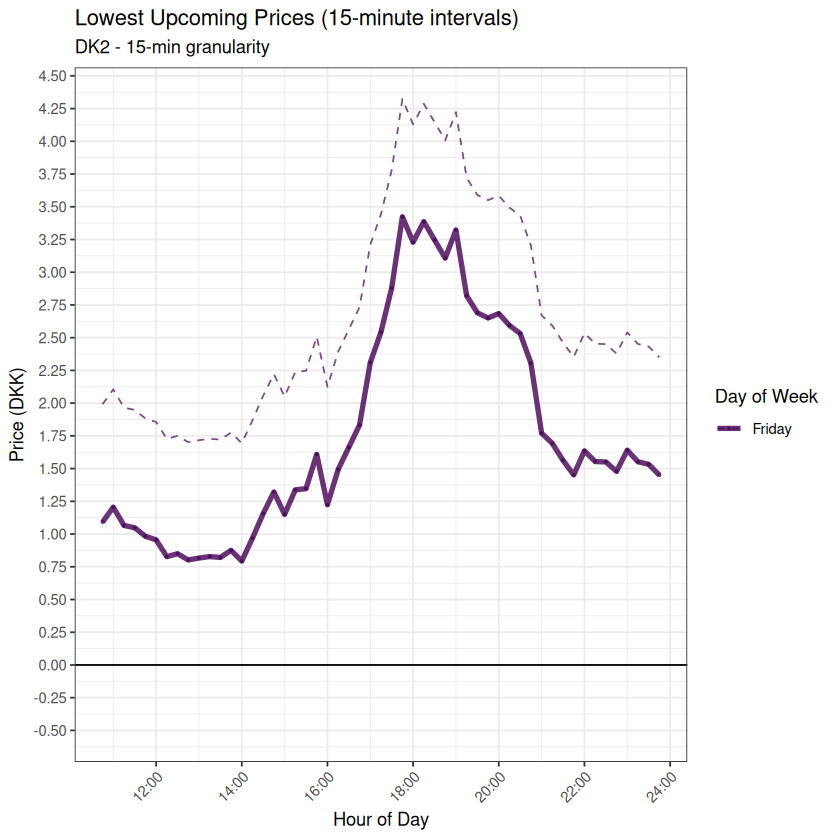

In [40]:
# Analysis with 15-minute granularity
df_previous <- df %>% 
  dplyr::select(Day, Hour, Minute, QuarterHour, SpotPriceDKK_Total_SansAfgift)

max_forecast_day <- lubridate::floor_date(max(df$HourDK), unit = "day")
min_forecast_day <- Sys.time()

lwr_upr <- df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(SpotPriceDKK_z = scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z <= 0) %>% 
  dplyr::mutate(Cheap = "Cheap")

# Create a decimal hour for plotting (e.g., 14.25 for 14:15)
p1 <- df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(HourDecimal = Hour + Minute/60) %>% 
  ggplot(., aes(x = HourDecimal, y = SpotPriceDKK_Total_SansAfgift, color = Day)) +
  geom_line(linewidth = 1.5, alpha = 0.8) +
  geom_point(size = 0.5, alpha = 0.6) +
  geom_line(aes(y = SpotPriceDKK_Total), linetype = 2, alpha = 0.7) +
  geom_hline(yintercept = 0) +
  scale_x_continuous(breaks = seq(0, 24, by = 2), labels = paste0(seq(0, 24, by = 2), ":00")) +
  scale_y_continuous(limits = c(-0.5, NA), breaks = seq(-1, 10, by = 0.25)) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Lowest Upcoming Prices (15-minute intervals)",
       subtitle = glue("{PRICE_AREA} - 15-min granularity"),
       x = "Hour of Day",
       y = "Price (DKK)") +
  guides(color = guide_legend(title = "Day of Week"))
p1

## Best Upcoming, All Day (15-minute detail)

Warning message:
“Using one column matrices in `filter()` or `filter_out()` was deprecated in
dplyr 1.1.0.
ℹ Please use one dimensional logical vectors instead.”


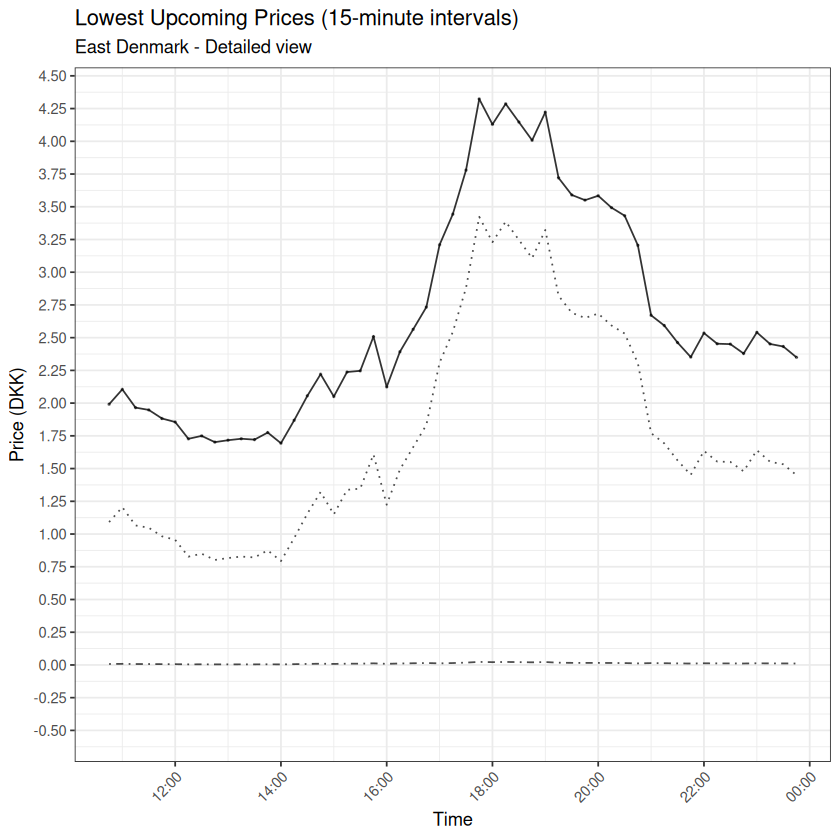

In [41]:
lwr_upr = df %>% 
  filter(HourDK >= Sys.time()) %>% 
  dplyr::mutate(SpotPriceDKK_z=scale(SpotPriceDKK_Total)) %>% 
  filter(SpotPriceDKK_z<=0) %>% 
  dplyr::mutate(Cheap="Cheap")

p2 = df %>% 
  filter(HourDK >= Sys.time()) %>% 
  ggplot(.,aes(x=HourDK,y=SpotPriceDKK_Total)) +
  geom_line(alpha=0.8) +
  geom_point(size=0.3, alpha=0.5) +  # Show individual 15-min points
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgift),linetype=3, alpha=0.7) +
  geom_line(aes(x=HourDK,y=SpotPriceDKK_Total_SansAfgiftTransport),linetype=4, alpha=0.7) +
  scale_x_datetime(date_breaks = "2 hours",date_labels = "%H:%M") +
  scale_y_continuous(limits=c(-0.5,NA),breaks = seq(-1,10,by=0.25)) +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  labs(title="Lowest Upcoming Prices (15-minute intervals)",
       subtitle="East Denmark - Detailed view",
       x="Time",
       y="Price (DKK)") +
  theme(legend.position="null")
p2

## Best 15-minute Windows (Multiple intervals)

In [49]:
max_forecast_day = lubridate::floor_date(max(df$HourDK),unit = "day")
min_forecast_day = Sys.time()

max_forecast_day

# Calculate mean/sd for 15-minute data in business hours
mean_sd = df %>% 
  filter(as.Date(HourDK)>=Sys.Date()-days(30)) %>% 
  filter(Hour >= 6) %>% 
  filter(Hour <= 17) %>% 
  dplyr::summarize(mean_=mean(SpotPriceDKK_Total_SansAfgift),sd_=sd(SpotPriceDKK_Total_SansAfgift))

# Rolling windows for 15-minute intervals
# Window sizes: 4=1hour, 8=2hours, 12=3hours, 16=4hours, 20=5hours
window_sizes = c(4, 8, 12, 16, 20)  # in 15-minute increments
window_labels = c("1h", "2h", "3h", "4h", "5h")

df_windows = lapply(seq_along(window_sizes), function(i) {
  window <- window_sizes[i]
  label <- window_labels[i]
  
  df %>% 
    filter(HourDK >= max_forecast_day) %>% 
    arrange(HourDK) %>% 
    dplyr::mutate(
      rollingsum = zoo::rollsum(x = SpotPriceDKK_Total_SansAfgift, k = window, fill = NA, align = "left"),
      window_15min = window,
      window_hours = label
    ) %>% 
    dplyr::mutate(rollingsum = rollingsum/window) %>% 
    dplyr::mutate(p_norm = pnorm(rollingsum, mean=mean_sd$mean_, sd=mean_sd$sd_)) %>% 
    dplyr::mutate(p_label = scales::percent(p_norm, accuracy=1)) %>% 
    na.omit
})
df_windows = do.call("rbind", df_windows)

# Find Pareto-optimal windows (min price, max duration) without rPref
res <- df_windows %>%
  arrange(rollingsum, desc(window_15min)) %>%
  dplyr::mutate(best_window_so_far = cummax(window_15min)) %>%
  dplyr::mutate(pareto = window_15min >= lag(best_window_so_far, default = -Inf)) %>%
  filter(pareto)

res %>% 
  dplyr::select(HourDK, QuarterHour, rollingsum, window_hours, p_norm) %>% 
  arrange(rollingsum, desc(window_hours)) %>%
  head(10) %>%
  knitr::kable(caption = "Best 15-minute window opportunities")

[1] "2026-03-06 CET"



Table: Best 15-minute window opportunities

|HourDK              |QuarterHour | rollingsum|window_hours |    p_norm|
|:-------------------|:-----------|----------:|:------------|---------:|
|2026-03-06 12:45:00 |12:45       |  0.8169116|1h           | 0.1544764|
|2026-03-06 12:15:00 |12:15       |  0.8238928|1h           | 0.1567373|
|2026-03-06 12:30:00 |12:30       |  0.8240329|1h           | 0.1567828|
|2026-03-06 12:15:00 |12:15       |  0.8266829|2h           | 0.1576469|
|2026-03-06 12:30:00 |12:30       |  0.8443577|2h           | 0.1634898|
|2026-03-06 12:00:00 |12:00       |  0.8469377|2h           | 0.1643543|
|2026-03-06 11:45:00 |11:45       |  0.8603631|2h           | 0.1689006|
|2026-03-06 11:30:00 |11:30       |  0.8807151|3h           | 0.1759451|
|2026-03-06 11:15:00 |11:15       |  0.8887937|3h           | 0.1787921|
|2026-03-06 11:45:00 |11:45       |  0.8897121|3h           | 0.1791176|

## 15-minute Window Analysis (All Day)

In [54]:
# Calculate percentiles for 15-minute rolling windows
mean_sd = df %>% 
  filter(as.Date(HourDK)>=Sys.Date()-days(30)) %>% 
  dplyr::summarize(mean_=mean(SpotPriceDKK_Total_SansAfgift),sd_=sd(SpotPriceDKK_Total_SansAfgift))

df_windows_allday = lapply(window_sizes, function(window) {
  
  # Create lookup table for percentiles
  look_up = data.frame(
    pct = seq(0,1,by=0.01),
    value = df %>% 
      filter(as.Date(HourDK)>=Sys.Date()-days(30)) %>% 
      arrange(HourDK) %>% 
      dplyr::mutate(rollingsum = zoo::rollsum(x = SpotPriceDKK_Total_SansAfgift, k = window, fill = NA, align = "left")) %>% 
      dplyr::mutate(rollingsum = rollingsum/window) %>% 
      pull(rollingsum) %>% 
      quantile(., seq(0,1,by=0.01), na.rm=T)
  )
  
  df %>% 
    filter(HourDK >= Sys.time()) %>% 
    arrange(HourDK) %>% 
    dplyr::mutate(
      rollingsum = zoo::rollsum(x = SpotPriceDKK_Total_SansAfgift, k = window, fill = NA, align = "left"),
      window_15min = window,
      window_hours = paste0(window/4, "h")
    ) %>% 
    dplyr::mutate(rollingsum = rollingsum/window) %>% 
    filter(rollingsum == min(rollingsum, na.rm=T)) %>% 
    tidyr::crossing(look_up) %>% 
    filter(rollingsum >= value) %>% 
    filter(pct == max(pct)) %>% 
    dplyr::mutate(p_label = scales::percent(pct, accuracy=1)) %>% 
    na.omit
})

df_windows_allday = do.call("rbind", df_windows_allday)

if(nrow(df_windows_allday) > 0) {
  res_2 <- df_windows_allday %>%
    arrange(rollingsum, desc(window_15min)) %>%
    dplyr::mutate(best_window_so_far = cummax(window_15min)) %>%
    dplyr::mutate(pareto = window_15min >= lag(best_window_so_far, default = -Inf)) %>%
    filter(pareto)
  
  res_2 %>% 
    dplyr::select(HourDK, QuarterHour, rollingsum, window_hours, pct) %>% 
    arrange(rollingsum, desc(window_hours)) %>%
    knitr::kable(caption = "Optimal 15-minute windows for lowest prices")
} else {
  cat("No future data available for window analysis\n")
}



Table: Optimal 15-minute windows for lowest prices

|HourDK              |QuarterHour | rollingsum|window_hours |  pct|
|:-------------------|:-----------|----------:|:------------|----:|
|2026-03-06 12:45:00 |12:45       |  0.8169116|1h           | 0.08|
|2026-03-06 12:15:00 |12:15       |  0.8266829|2h           | 0.08|
|2026-03-06 11:30:00 |11:30       |  0.8807151|3h           | 0.10|
|2026-03-06 10:45:00 |10:45       |  0.9429173|4h           | 0.13|
|2026-03-06 10:45:00 |10:45       |  1.0121046|5h           | 0.17|

## 15-minute Price Visualization

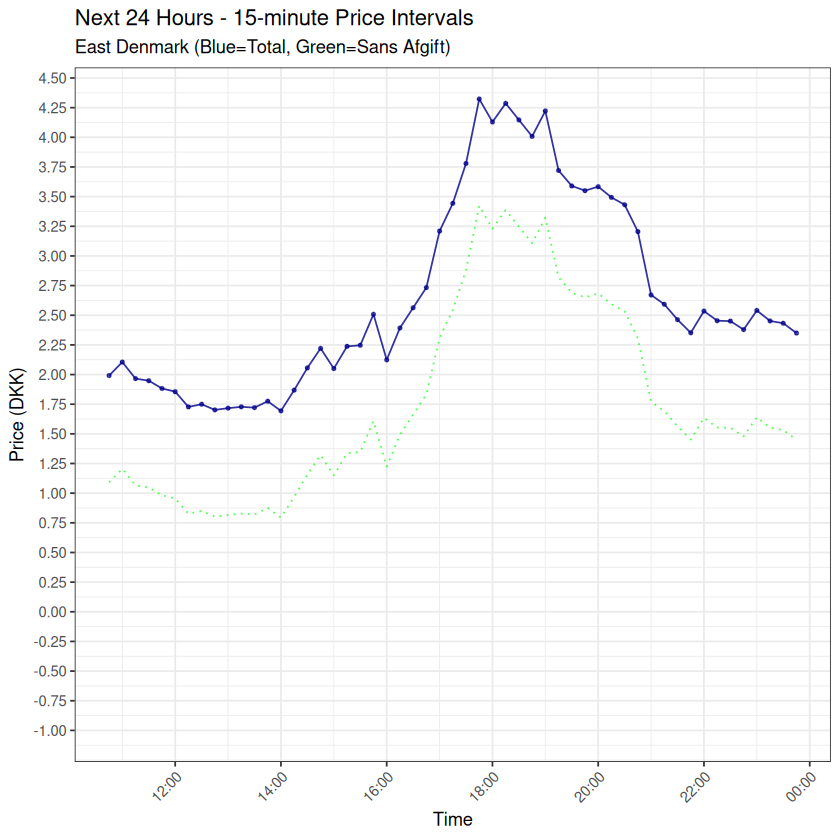

In [55]:
# Visualize upcoming prices with 15-minute detail
min_forecast_day = Sys.time()

df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  filter(HourDK <= min_forecast_day + hours(24)) %>%  # Next 24 hours
  ggplot(., aes(x=HourDK, y=SpotPriceDKK_Total)) +
  geom_line(alpha=0.8, color="darkblue") +
  geom_point(size=0.8, alpha=0.7, color="darkblue") +  # Show each 15-min point
  geom_line(aes(x=HourDK, y=SpotPriceDKK_Total_SansAfgift), linetype=3, alpha=0.7, color="green") +
  scale_y_continuous(limits=c(-1,NA), breaks = seq(-1,10,by=0.25)) +
  scale_x_datetime(date_breaks = "2 hours", date_labels = "%H:%M") +
  theme_bw() +
  theme(axis.text.x=element_text(angle=45,hjust=1)) +
  labs(title="Next 24 Hours - 15-minute Price Intervals",
       subtitle="East Denmark (Blue=Total, Green=Sans Afgift)",
       x="Time",
       y="Price (DKK)") +
  theme(legend.position="null")

## Last Week & Upcoming (15-minute heatmap)

Date range for heatmap: 2026-02-27 to 2026-03-06 
Rows in heatmap data: 768 
HourDecimal range: 0 to 23.75 
Price range: 1.356976 to 6.008547 


Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_tile()`).”


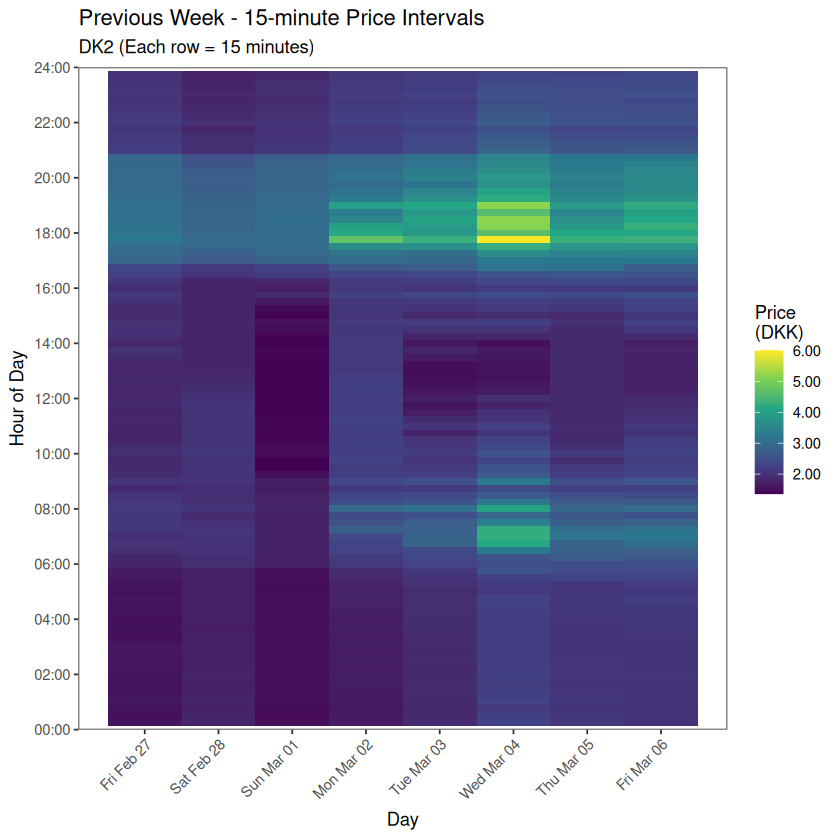

In [56]:
max_forecast_day <- lubridate::floor_date(max(df$HourDK), unit = "day")
min_forecast_day <- max_forecast_day - days(7)

# Debug: check data
cat("Date range for heatmap:", as.character(min_forecast_day), "to",  as.character(max_forecast_day), "\n")

# Create heatmap data
heatmap_data <- df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(
    Day_Num = lubridate::floor_date(HourDK, unit = "day"),
    HourDecimal = Hour + Minute/60
  )

cat("Rows in heatmap data:", nrow(heatmap_data), "\n")
cat("HourDecimal range:", min(heatmap_data$HourDecimal), "to", max(heatmap_data$HourDecimal), "\n")
cat("Price range:", min(heatmap_data$SpotPriceDKK_Total, na.rm=TRUE), "to", max(heatmap_data$SpotPriceDKK_Total, na.rm=TRUE), "\n")

# Create heatmap with 15-minute resolution and viridis colors
heatmap_data %>% 
  ggplot(aes(x = Day_Num, y = HourDecimal, fill = SpotPriceDKK_Total)) +
  geom_tile(width = 86400, height = 0.25) +  # width in seconds (1 day = 86400 seconds)
  scale_fill_viridis_c(
    option = "viridis",
    name = "Price\n(DKK)",
    labels = scales::number_format(accuracy = 0.01)
  ) +
  scale_x_datetime(date_breaks = "1 day", date_labels = "%a %b %d") +
  scale_y_continuous(
    breaks = seq(0, 24, by = 2), 
    labels = paste0(sprintf("%02d", seq(0, 24, by = 2)), ":00"),
    expand = c(0, 0),
    limits = c(0, 24)
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  labs(title = "Previous Week - 15-minute Price Intervals",
       subtitle = glue("{PRICE_AREA} (Each row = 15 minutes)"),
       x = "Day",
       y = "Hour of Day")

25th Percentile Threshold: 1.800287 DKK


Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_tile()`).”


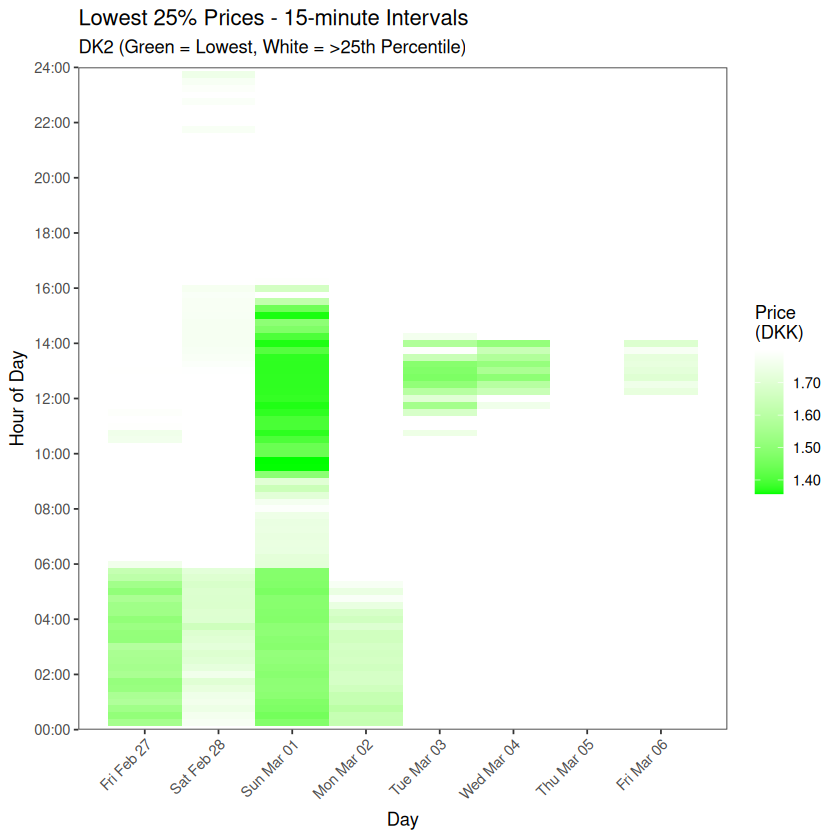

In [57]:
# Calculate 25th percentile for the displayed period
threshold_25 <- quantile(heatmap_data$SpotPriceDKK_Total, 0.25, na.rm = TRUE)

cat("25th Percentile Threshold:", threshold_25, "DKK\n")

# Create heatmap with custom gradient for lowest 25%
heatmap_data %>% 
  dplyr::mutate(
    # Keep only lowest 25%, others become NA
    SpotPrice_Low = ifelse(SpotPriceDKK_Total <= threshold_25, SpotPriceDKK_Total, NA)
  ) %>%
  ggplot(aes(x = Day_Num, y = HourDecimal, fill = SpotPrice_Low)) +
  geom_tile(width = 86400, height = 0.25) +
  scale_fill_gradient(
    low = "green",      # Lowest prices are green
    high = "white",     # Prices near threshold are white
    na.value = "white", # Prices above threshold are white
    name = "Price\n(DKK)",
    labels = scales::number_format(accuracy = 0.01)
  ) +
  scale_x_datetime(date_breaks = "1 day", date_labels = "%a %b %d") +
  scale_y_continuous(
    breaks = seq(0, 24, by = 2), 
    labels = paste0(sprintf("%02d", seq(0, 24, by = 2)), ":00"),
    expand = c(0, 0),
    limits = c(0, 24)
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  labs(title = "Lowest 25% Prices - 15-minute Intervals",
       subtitle = glue("{PRICE_AREA} (Green = Lowest, White = >25th Percentile)"),
       x = "Day",
       y = "Hour of Day")

Date range for heatmap: 2026-02-27 to 2026-03-06 
Rows in heatmap data: 768 
HourDecimal range: 0 to 23.75 
Price range: 1.356976 to 6.008547 


Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_tile()`).”


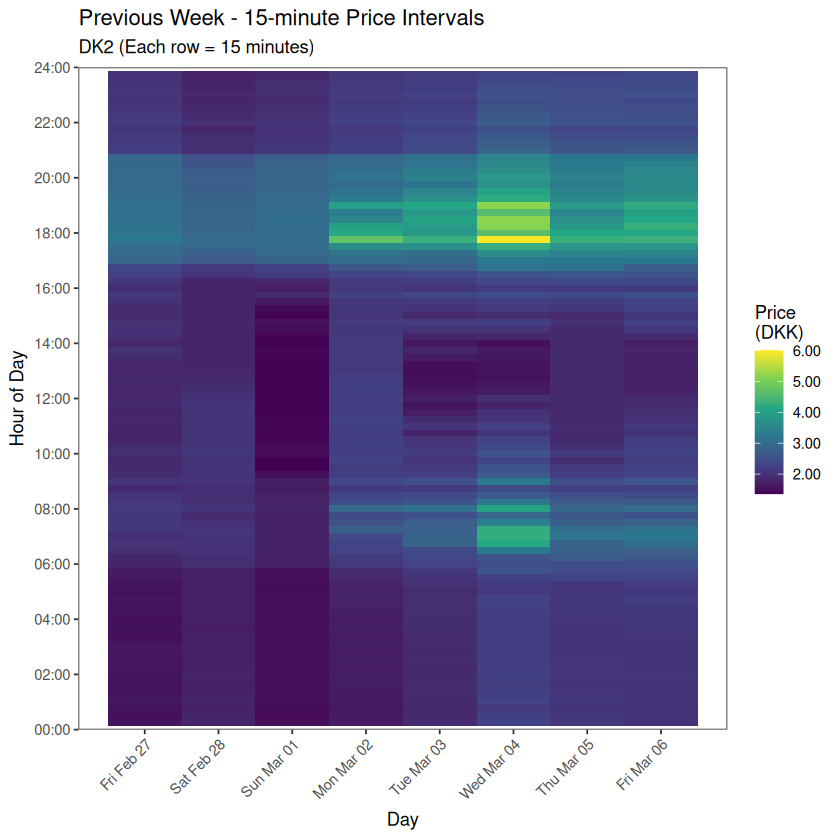

In [36]:
max_forecast_day <- lubridate::floor_date(max(df$HourDK), unit = "day")
min_forecast_day <- max_forecast_day - days(7)

# Debug: check data
cat("Date range for heatmap:", as.character(min_forecast_day), "to",  as.character(max_forecast_day), "\n")

# Create heatmap data
heatmap_data <- df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(
    Day_Num = lubridate::floor_date(HourDK, unit = "day"),
    HourDecimal = Hour + Minute/60
  )

cat("Rows in heatmap data:", nrow(heatmap_data), "\n")
cat("HourDecimal range:", min(heatmap_data$HourDecimal), "to", max(heatmap_data$HourDecimal), "\n")
cat("Price range:", min(heatmap_data$SpotPriceDKK_Total, na.rm=TRUE), "to", max(heatmap_data$SpotPriceDKK_Total, na.rm=TRUE), "\n")

# Create heatmap with 15-minute resolution and viridis colors
heatmap_data %>% 
  ggplot(aes(x = Day_Num, y = HourDecimal, fill = SpotPriceDKK_Total)) +
  geom_tile(width = 86400, height = 0.25) +  # width in seconds (1 day = 86400 seconds)
  scale_fill_viridis_c(
    option = "viridis",
    name = "Price\n(DKK)",
    labels = scales::number_format(accuracy = 0.01)
  ) +
  scale_x_datetime(date_breaks = "1 day", date_labels = "%a %b %d") +
  scale_y_continuous(
    breaks = seq(0, 24, by = 2), 
    labels = paste0(sprintf("%02d", seq(0, 24, by = 2)), ":00"),
    expand = c(0, 0),
    limits = c(0, 24)
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  labs(title = "Previous Week - 15-minute Price Intervals",
       subtitle = glue("{PRICE_AREA} (Each row = 15 minutes)"),
       x = "Day",
       y = "Hour of Day")

## Weekly Pattern Analysis (15-minute averages by time slot)

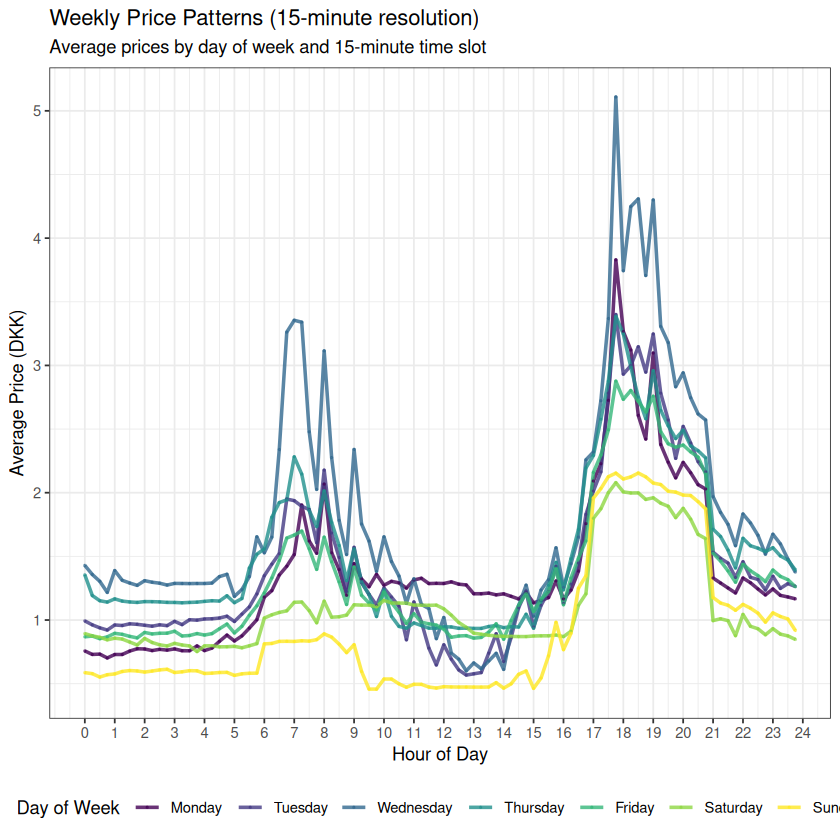

In [39]:
max_forecast_day <- lubridate::floor_date(max(df$HourDK), unit = "day")
min_forecast_day <- max_forecast_day - days(7)

# Analyze patterns by 15-minute time slots
weekly_pattern <- df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(
    Weekday = factor(wday(HourDK, label = TRUE, abbr = FALSE), levels = DAY_ORDER),
    TimeSlot = format_time_slot(Hour, Minute)
  ) %>% 
  group_by(Weekday, TimeSlot, Hour, Minute) %>% 
  dplyr::summarise(
    AvgPrice = mean(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE),
    Count = n(),
    .groups = "drop"
  ) %>% 
  dplyr::mutate(HourDecimal = Hour + Minute/60)

# Visualization of weekly 15-minute patterns
weekly_pattern %>% 
  ggplot(aes(x = HourDecimal, y = AvgPrice, color = Weekday)) +
  geom_line(alpha = 0.8, linewidth = 1) +
  geom_point(size = 0.3, alpha = 0.6) +
  scale_x_continuous(breaks = seq(0, 24, by = 1), labels = paste0(seq(0, 24, by = 1))) +
  theme_bw() +
  labs(title = "Weekly Price Patterns (15-minute resolution)",
       subtitle = "Average prices by day of week and 15-minute time slot",
       x = "Hour of Day",
       y = "Average Price (DKK)",
       color = "Day of Week") +
  theme(legend.position = "bottom") +
  guides(color = guide_legend(nrow = 1))

## 15-minute Price Distribution Analysis

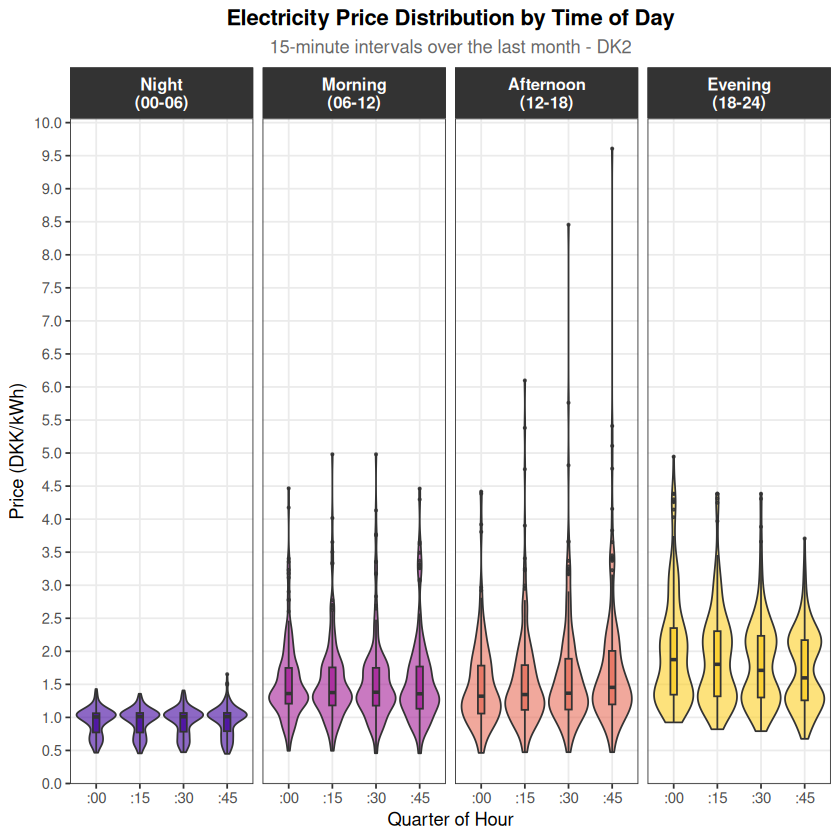

In [42]:
# Analyze price distribution by 15-minute time slots over the last month
max_forecast_day <- lubridate::floor_date(max(df$HourDK), unit = "day")
min_forecast_day <- max_forecast_day - months(1)

# Create clean data with proper ordering
price_distribution <- df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::mutate(
    HourDecimal = Hour + Minute/60,
    QuarterLabel = case_when(
      Minute == 0 ~ ":00",
      Minute == 15 ~ ":15",
      Minute == 30 ~ ":30",
      Minute == 45 ~ ":45"
    ),
    TimePeriod = case_when(
      Hour %in% 0:5 ~ "Night\n(00-06)",
      Hour %in% 6:11 ~ "Morning\n(06-12)",
      Hour %in% 12:17 ~ "Afternoon\n(12-18)",
      Hour %in% 18:23 ~ "Evening\n(18-24)"
    ),
    TimePeriod = factor(TimePeriod, levels = c("Night\n(00-06)", "Morning\n(06-12)", 
                                                "Afternoon\n(12-18)", "Evening\n(18-24)"))
  )

# Violin + boxplot showing price distribution by time period and quarter
price_distribution %>% 
  ggplot(aes(x = QuarterLabel, y = SpotPriceDKK_Total_SansAfgift, fill = TimePeriod)) +
  geom_violin(alpha = 0.6, scale = "width", trim = TRUE) +
  geom_boxplot(width = 0.15, alpha = 0.8, outlier.size = 0.5) +
  scale_fill_viridis_d(option = "plasma", begin = 0.1, end = 0.9) +
  scale_y_continuous(
    breaks = seq(0, ceiling(max(price_distribution$SpotPriceDKK_Total_SansAfgift, na.rm = TRUE)), by = 0.5),
    labels = scales::number_format(accuracy = 0.1)
  ) +
  facet_wrap(~TimePeriod, nrow = 1, scales = "fixed") +
  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey20"),
    strip.text = element_text(color = "white", face = "bold", size = 10),
    axis.text.x = element_text(size = 9),
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title = element_text(hjust = 0.5, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5, color = "grey40")
  ) +
  labs(
    title = "Electricity Price Distribution by Time of Day",
    subtitle = glue("15-minute intervals over the last month - {PRICE_AREA}"),
    x = "Quarter of Hour",
    y = "Price (DKK/kWh)"
  )

## Intraday Volatility Analysis (15-minute changes)

`geom_smooth()` using formula = 'y ~ x'



15-minute volatility summary (last 7 days):
  Mean_Abs_Change Median_Abs_Change Max_Change Std_Dev Total_Changes
1          0.1202            0.0564     1.7397  0.1767           764


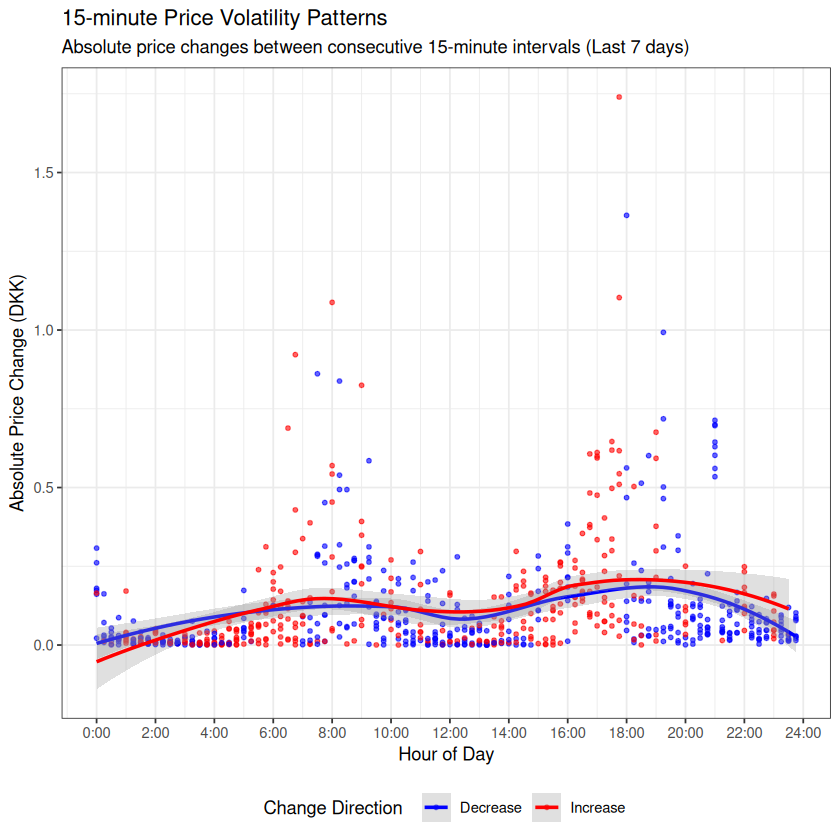

In [44]:
# Calculate price changes between consecutive 15-minute intervals
volatility_analysis = df %>% 
  arrange(HourDK) %>% 
  dplyr::mutate(
    Price_Change_15min = SpotPriceDKK_Total_SansAfgift - lag(SpotPriceDKK_Total_SansAfgift),
    Price_Change_Pct = (Price_Change_15min / lag(SpotPriceDKK_Total_SansAfgift)) * 100,
    Abs_Change = abs(Price_Change_15min)
  ) %>% 
  filter(!is.na(Price_Change_15min)) %>%
  filter(as.Date(HourDK) >= Sys.Date() - days(7)) %>%  # Last week
  dplyr::mutate(
    HourDecimal = Hour + Minute/60,
    ChangeDirection = ifelse(Price_Change_15min > 0, "Increase", "Decrease")
  )

# Plot showing 15-minute price volatility throughout the day
volatility_analysis %>% 
  ggplot(aes(x=HourDecimal, y=Abs_Change, color=ChangeDirection)) +
  geom_point(alpha=0.6, size=1) +
  geom_smooth(method="loess", se=TRUE, alpha=0.3) +
  scale_x_continuous(breaks = seq(0,24,by=2), labels = paste0(seq(0,24,by=2), ":00")) +
  scale_color_manual(values = c("Increase" = "red", "Decrease" = "blue")) +
  theme_bw() +
  labs(title="15-minute Price Volatility Patterns",
       subtitle="Absolute price changes between consecutive 15-minute intervals (Last 7 days)",
       x="Hour of Day",
       y="Absolute Price Change (DKK)",
       color="Change Direction") +
  theme(legend.position="bottom")

# Summary statistics
cat("\n15-minute volatility summary (last 7 days):\n")
volatility_summary = volatility_analysis %>% 
  dplyr::summarise(
    Mean_Abs_Change = round(mean(Abs_Change, na.rm=TRUE), 4),
    Median_Abs_Change = round(median(Abs_Change, na.rm=TRUE), 4),
    Max_Change = round(max(Abs_Change, na.rm=TRUE), 4),
    Std_Dev = round(sd(Abs_Change, na.rm=TRUE), 4),
    Total_Changes = n()
  )
print(volatility_summary)

## Time Windows with 15-minute Precision

In [45]:
# =============================================================================
# DECISION TREE MODEL - 15-minute precision
# =============================================================================
cat("Running patched decision-tree cell (fallback enabled)\n")

# Prepare training data with consistent day ordering
df_predict_15min <- df %>% 
  filter(HourDK >= Sys.Date() - months(MODEL_LOOKBACK_MONTHS)) %>% 
  dplyr::mutate(
    Hour = hour(HourDK),
    Minute = minute(HourDK),
    QuarterHour = Minute %/% 15,  # 0, 1, 2, 3 for each 15-min interval
    Day = factor(wday(HourDK, label = TRUE, abbr = FALSE), levels = DAY_ORDER),
    HourDecimal = Hour + Minute/60
  ) %>% 
  dplyr::select(SpotPriceDKK_Total_SansAfgift, Hour, Minute, QuarterHour, Day, HourDecimal)

cat(glue("Training model on {nrow(df_predict_15min)} observations\n"))

# Train model with 15-minute features
set.seed(123)
train_control <- caret::trainControl(method = "repeatedcv", number = 5, repeats = 3)
fit_rpart_15min <- caret::train(
  y = df_predict_15min$SpotPriceDKK_Total_SansAfgift,
  x = df_predict_15min %>% dplyr::select(-SpotPriceDKK_Total_SansAfgift) %>% as.data.frame(),
  method = "rpart",
  tuneLength = 20,
  metric = "RMSE",
  trControl = train_control
)

cat(glue("\nModel RMSE: {round(min(fit_rpart_15min$results$RMSE), 4)}\n"))

if (requireNamespace("rpart.plot", quietly = TRUE)) {
  rpart.plot::rpart.plot(fit_rpart_15min$finalModel, main = "Price Prediction Rules (15-min precision)")
  cat("\nDecision tree rules for 15-minute price prediction:\n")
  rpart.plot::rpart.rules(fit_rpart_15min$finalModel)
} else {
  cat("\nrpart.plot not available; using base rpart tree plot and summary.\n")
  plot(fit_rpart_15min$finalModel, uniform = TRUE, margin = 0.1)
  text(fit_rpart_15min$finalModel, use.n = TRUE, cex = 0.7)
  cat("\nDecision tree summary:\n")
  print(summary(fit_rpart_15min$finalModel))
}

Training model on 11666 observations

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


Model RMSE: 0.4009

ERROR: Error in rpart.plot(fit_rpart_15min$finalModel, main = "Price Prediction Rules (15-min precision)"): could not find function "rpart.plot"


## Predicted Cost Heatmap (rpart model)

This heatmap shows the **expected electricity cost per kWh** based on the rpart decision tree model predictions. 
- **X-axis**: Day of week (Monday to Sunday)
- **Y-axis**: Time of day in 15-minute intervals (00:00 at bottom)
- **Colors**: Viridis palette (purple = low cost, yellow = high cost)

Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_tile()`).”



Predicted price summary by day:




|Day       |   Min|  Mean|   Max|
|:---------|-----:|-----:|-----:|
|Monday    | 0.737| 1.415| 2.740|
|Tuesday   | 0.851| 1.483| 2.740|
|Wednesday | 0.851| 1.483| 2.740|
|Thursday  | 0.851| 1.354| 2.335|
|Friday    | 0.851| 1.354| 2.335|
|Saturday  | 0.851| 1.254| 2.147|
|Sunday    | 0.851| 1.254| 2.147|

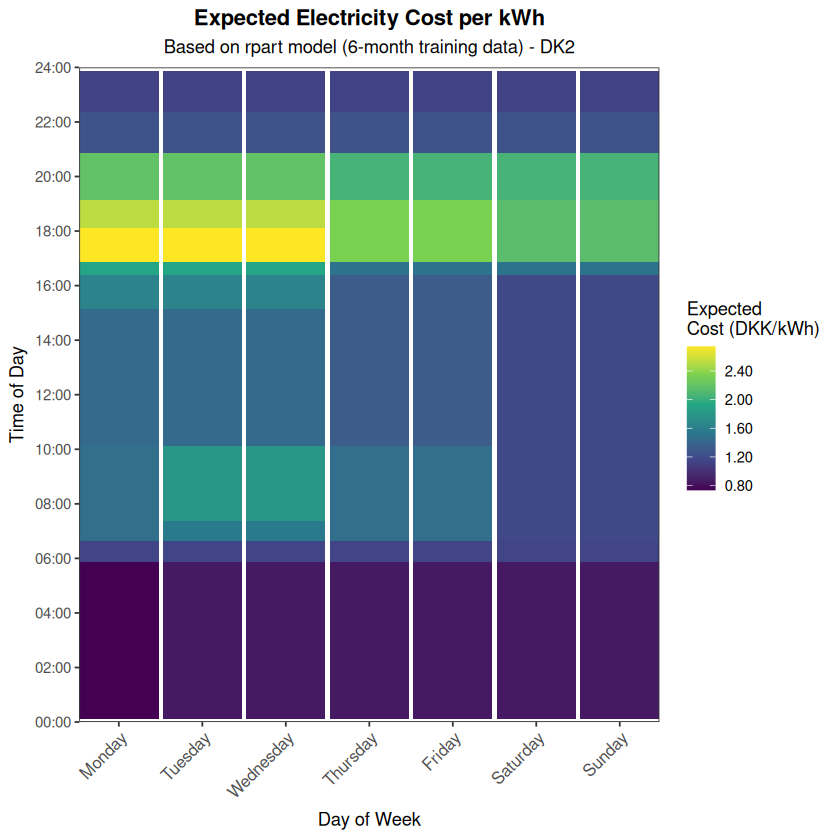

In [46]:
# =============================================================================
# PREDICTED COST HEATMAP - Based on rpart model
# =============================================================================

# Create prediction grid for all Day × Hour × Minute combinations
# Use ordered factor to match the model's training data (wday with label=TRUE returns ordered)
prediction_grid <- expand.grid(
  Day = factor(DAY_ORDER, levels = DAY_ORDER, ordered = TRUE),
  Hour = 0:23,
  Minute = c(0, 15, 30, 45),
  stringsAsFactors = FALSE
) %>% 
  dplyr::mutate(
    QuarterHour = Minute %/% 15,
    HourDecimal = Hour + Minute/60,
    TimeLabel = format_time_slot(Hour, Minute)
  )

# Generate predictions
prediction_grid$PredictedPrice <- predict(
  fit_rpart_15min$finalModel, 
  newdata = prediction_grid
)

# Create heatmap with viridis colors
# Y-axis: 00:00 at bottom (default ascending order)
heatmap_predicted <- prediction_grid %>% 
  ggplot(aes(x = Day, y = HourDecimal, fill = PredictedPrice)) +
  geom_tile(width = 0.95, height = 0.25) +
  scale_fill_viridis_c(
    option = "viridis",
    name = "Expected\nCost (DKK/kWh)",
    labels = scales::number_format(accuracy = 0.01)
  ) +
  scale_y_continuous(
    breaks = seq(0, 24, by = 2),
    labels = paste0(sprintf("%02d", seq(0, 24, by = 2)), ":00"),
    expand = c(0, 0),
    limits = c(0, 24)
  ) +
  scale_x_discrete(expand = c(0, 0)) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 10),
    axis.text.y = element_text(size = 9),
    legend.position = "right",
    plot.title = element_text(hjust = 0.5, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5)
  ) +
  labs(
    title = "Expected Electricity Cost per kWh",
    subtitle = glue("Based on rpart model ({MODEL_LOOKBACK_MONTHS}-month training data) - {PRICE_AREA}"),
    x = "Day of Week",
    y = "Time of Day"
  )

heatmap_predicted

# Summary statistics
cat("\nPredicted price summary by day:\n")
prediction_grid %>% 
  group_by(Day) %>% 
  dplyr::summarise(
    Min = round(min(PredictedPrice), 3),
    Mean = round(mean(PredictedPrice), 3),
    Max = round(max(PredictedPrice), 3),
    .groups = "drop"
  ) %>% 
  knitr::kable()

# Seasonal Analysis with 15-minute Precision

In [47]:
# Seasonal analysis maintaining 15-minute granularity
library(dplyr)
library(ggplot2)
library(knitr)

# Create time period categories with 15-minute precision
df_analysis_15min <- df %>%
  filter(!is.na(SpotPriceDKK_Total_SansAfgift)) %>%
  dplyr::mutate(
    Month = month(HourDK, label = TRUE),
    Hour = hour(HourDK),
    Minute = minute(HourDK),
    QuarterHour = paste0(sprintf("%02d", Hour), ":", sprintf("%02d", Minute)),
    TimePeriod = case_when(
      Hour %in% c(21, 22, 23, 0, 1, 2, 3, 4, 5) ~ "Night (21:00-05:59)",
      Hour %in% c(11, 12, 13, 14, 15, 16) ~ "Day (11:00-16:59)",
      TRUE ~ "Other"
    )
  ) %>%
  filter(TimePeriod != "Other") %>%
  dplyr::select(Month, TimePeriod, QuarterHour, SpotPriceDKK_Total_SansAfgift, HourDK)

# Summary table by month and time period (15-minute data points)
summary_table_15min <- df_analysis_15min %>%
  group_by(Month, TimePeriod) %>%
  dplyr::summarise(
    Count_15min_intervals = n(),
    Mean = round(mean(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    Median = round(median(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    Min = round(min(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    Max = round(max(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    SD = round(sd(SpotPriceDKK_Total_SansAfgift, na.rm = TRUE), 3),
    .groups = "drop"
  ) %>%
  arrange(Month, TimePeriod)

cat("Seasonal analysis with 15-minute data points:\n")
print(summary_table_15min)

Seasonal analysis with 15-minute data points:
# A tibble: 10 × 8
   Month TimePeriod         Count_15min_intervals  Mean Median   Min   Max    SD
   <ord> <chr>                              <int> <dbl>  <dbl> <dbl> <dbl> <dbl>
 1 Jan   Day (11:00-16:59)                    744 1.49   1.42  0.407  3.66 0.397
 2 Jan   Night (21:00-05:5…                  1116 1.03   1.05  0.144  1.90 0.28 
 3 Feb   Day (11:00-16:59)                    672 1.44   1.36  0.795  4.16 0.428
 4 Feb   Night (21:00-05:5…                  1008 1.04   1.03  0.449  1.86 0.233
 5 Mar   Day (11:00-16:59)                    144 1.03   0.984 0.463  2.26 0.358
 6 Mar   Night (21:00-05:5…                   216 1.14   1.14  0.552  1.97 0.316
 7 Nov   Day (11:00-16:59)                    622 1.41   1.26  0.607  4.44 0.582
 8 Nov   Night (21:00-05:5…                   912 0.894  0.94  0.162  1.97 0.309
 9 Dec   Day (11:00-16:59)                    744 1.24   1.16  0.467  3.71 0.354
10 Dec   Night (21:00-05:5…                 

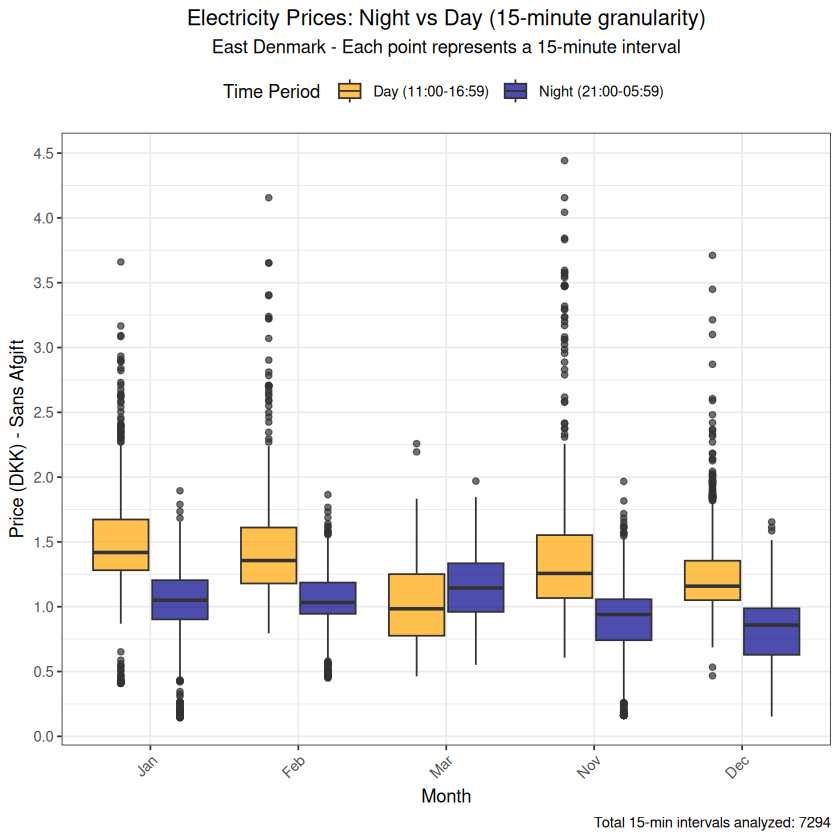

In [48]:
# Boxplot with 15-minute data points
boxplot_15min <- ggplot(df_analysis_15min, aes(x = Month, y = SpotPriceDKK_Total_SansAfgift, fill = TimePeriod)) +
  geom_boxplot(position = position_dodge(width = 0.8), alpha = 0.7) +
  scale_fill_manual(values = c("Night (21:00-05:59)" = "darkblue", "Day (11:00-16:59)" = "orange")) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "top",
    plot.title = element_text(hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5)
  ) +
  labs(
    title = "Electricity Prices: Night vs Day (15-minute granularity)",
    subtitle = "East Denmark - Each point represents a 15-minute interval",
    x = "Month",
    y = "Price (DKK) - Sans Afgift",
    fill = "Time Period",
    caption = paste("Total 15-min intervals analyzed:", nrow(df_analysis_15min))
  ) +
  scale_y_continuous(breaks = seq(0, ceiling(max(df_analysis_15min$SpotPriceDKK_Total_SansAfgift, na.rm = TRUE)), by = 0.5))

boxplot_15min

# Cost Analysis with 15-minute Precision

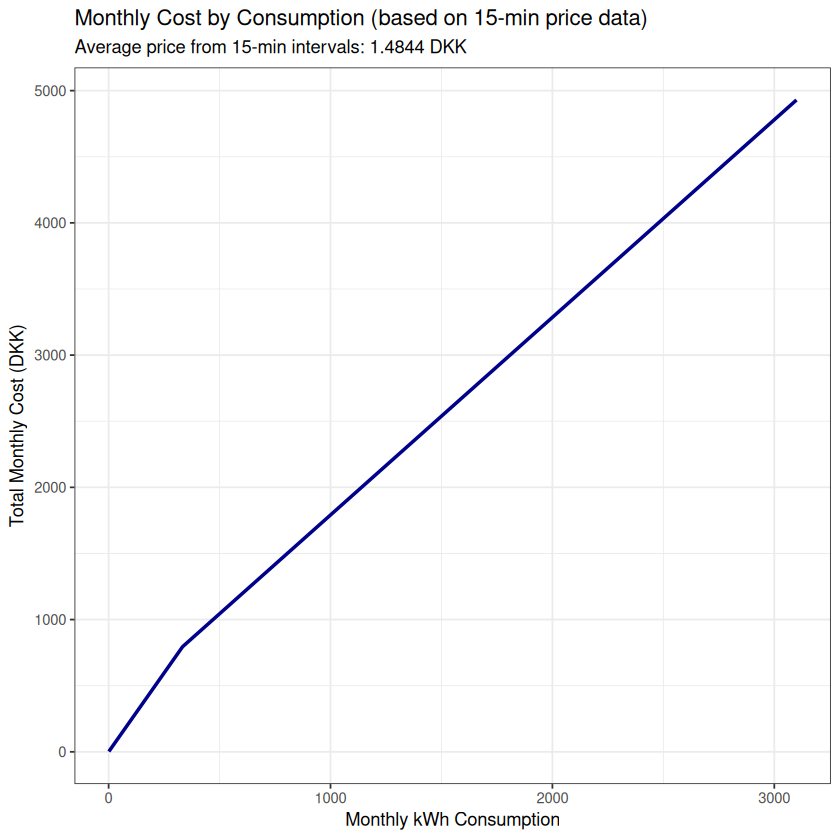

In [50]:
# Calculate average prices with 15-minute precision for cost modeling
max_forecast_day <- lubridate::floor_date(max(df$HourDK), unit = "day")
min_forecast_day <- max_forecast_day - months(1)

# Calculate mean prices using 15-minute data points (not hourly aggregates)
mean_price_spot_15min <- df %>% 
  filter(HourDK >= min_forecast_day) %>% 
  dplyr::summarize(SpotPriceMean = mean(SpotPriceDKK_Total_SansAfgift)) %>% 
  pull(SpotPriceMean)

# Cost analysis using 15-minute granularity pricing
expand.grid(kwh = seq(100 * 31)) %>% 
  dplyr::mutate(
    over4k = case_when(kwh > (4000/12) ~ kwh - (4000/12), TRUE ~ 0),
    under4k = case_when(kwh <= (4000/12) ~ kwh, TRUE ~ (4000/12)),
    afgift = 0.90 * under4k + 0.01 * over4k,
    SpotPriceDKK = kwh * mean_price_spot_15min + afgift
  ) %>% 
  ggplot(aes(x = kwh, y = SpotPriceDKK)) +
  geom_line(color = "darkblue", linewidth = 1) +
  labs(title = "Monthly Cost by Consumption (based on 15-min price data)",
       subtitle = paste("Average price from 15-min intervals:", round(mean_price_spot_15min, 4), "DKK"),
       x = "Monthly kWh Consumption",
       y = "Total Monthly Cost (DKK)") +
  theme_bw()

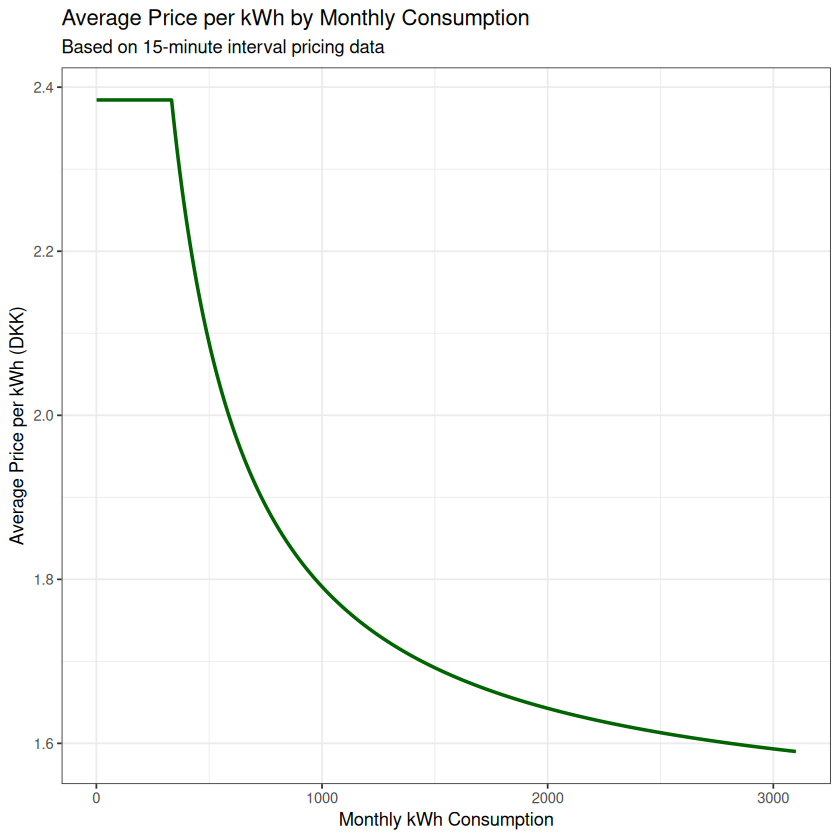

In [52]:
# Average price per kWh with 15-minute precision
expand.grid(kwh = seq(100 * 31)) %>% 
  dplyr::mutate(
    over4k = case_when(kwh > (4000/12) ~ kwh - (4000/12), TRUE ~ 0),
    under4k = case_when(kwh <= (4000/12) ~ kwh, TRUE ~ (4000/12)),
    afgift = 0.90 * under4k + 0.01 * over4k,
    SpotPriceDKK = kwh * mean_price_spot_15min + afgift,
    AvgPricePerKWh = SpotPriceDKK / kwh
  ) %>% 
  ggplot(aes(x = kwh, y = AvgPricePerKWh)) +
  geom_line(color = "darkgreen", linewidth = 1) +
  labs(title = "Average Price per kWh by Monthly Consumption",
       subtitle = "Based on 15-minute interval pricing data",
       x = "Monthly kWh Consumption",
       y = "Average Price per kWh (DKK)") +
  theme_bw()

# Send Notifications (15-minute precision)

In [53]:
# Send notifications with 15-minute precision
tmp_dir = tempdir()
ggsave(filename = paste0(tmp_dir,"/p1_15min.jpg"), plot = p1, device = "jpeg", width = 10, height = 6)
pushoverr::pushover(message = "Electricity Forecast (15-min intervals - New API)", attachment = paste0(tmp_dir,"/p1_15min.jpg"))

# Best 15-minute windows
if(exists("res") && nrow(res) > 0) {
  msg_15min = res %>% 
    dplyr::mutate(
      diff_hours = as.numeric(difftime(HourDK, as.POSIXct(Sys.Date()+hours(6), tz="Europe/Copenhagen"), units = "mins"))/60
    ) %>% 
    dplyr::mutate(
      label_ = glue("{window_hours} Window: {QuarterHour} - {scales::number(rollingsum,accuracy=0.001)} DKK ({p_label}), Delay: {round(diff_hours,1)}h")
    ) %>% 
    arrange(rollingsum) %>%
    head(5) %>%  # Top 5 opportunities
    pull(label_) %>% 
    paste(., collapse="\n")
  
  msg_15min = paste0("BEST 15-MIN ELECTRICITY WINDOWS:\n", msg_15min)
  pushoverr::pushover(message = msg_15min)
} else {
  pushoverr::pushover(message = "15-min analysis complete - no future windows available")
}

cat("Notifications sent with 15-minute precision data!\n")

Notifications sent with 15-minute precision data!


## API Comparison and 15-minute Analysis Summary

This notebook uses the new **DayAheadPrices** API endpoint with **full 15-minute granularity**:

### 🔄 **API Changes:**
- **Old API**: `Elspotprices` with hourly data
- **New API**: `DayAheadPrices` with 15-minute intervals
- **Field Mapping**: `HourDK` → `TimeDK`, `SpotPriceDKK` → `DayAheadPriceDKK`, etc.

### ⏰ **15-minute Precision Benefits:**
- **Higher Resolution**: 4x more data points per hour
- **Intraday Patterns**: Capture price movements within each hour
- **Better Optimization**: Find optimal 15-minute time slots for electricity usage
- **Volatility Analysis**: Understand price changes between 15-minute intervals

### 📊 **Analysis Adaptations:**
- **Rolling Windows**: Now calculated in 15-minute increments (4=1h, 8=2h, etc.)
- **Visualizations**: Points and lines show individual 15-minute intervals
- **Time Slots**: Analysis by exact 15-minute time slots (e.g., "14:15", "14:30")
- **Volatility**: Track price changes between consecutive 15-minute periods

### 🎯 **Key Features:**
- All original functionality preserved but enhanced with 15-minute precision
- Transport costs still applied hourly (as per regulation)
- Decision trees now include 15-minute timing features
- Notifications include exact 15-minute optimal time slots

**Total Data Points**: ~4x more granular than the original hourly analysis, providing much more precise insights for electricity usage optimization.